# Jupyter Notebook 2. Эксперименты с моделями и валидация

**Стажёр:** [Дмитрий]

На входе — готовый датасет, подготовленный ранее и разделённый на тренировочную и тестовую выборки.

На выходе — финальная модель, карточка модели и SHAP-анализ.

## 1. Подключение библиотек

In [9]:
import pandas as pd
import numpy as np

import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier


from sklearn.model_selection import train_test_split


from sklearn.model_selection import cross_val_score, StratifiedKFold

import optuna
import shap

import warnings
warnings.filterwarnings("ignore")
from IPython.display import display

import joblib
import os


RANDOM_STATE = 42

## 2. Загрузка данных

Загрузите `train` и `test` выборки из тетради 1. Проверьте размеры выборок и баланс классов.

In [10]:
# ==========================================
# 2. Загрузка данных
# ==========================================


X_train = joblib.load("X_train.pkl")
X_test = joblib.load("X_test.pkl")

y_train = joblib.load("y_train.pkl")
y_test = joblib.load("y_test.pkl")

preprocessor=joblib.load('preprocessor.pkl')

print("Train:")
print(X_train.shape)

print("\nTest:")
print(X_test.shape)



print("\nБаланс train:")
print(y_train.value_counts(normalize=True))


print("\nБаланс test:")
print(y_test.value_counts(normalize=True))

Train:
(268999, 51)

Test:
(67250, 51)

Баланс train:
is_high_demand
0    0.876799
1    0.123201
Name: proportion, dtype: float64

Баланс test:
is_high_demand
0    0.876803
1    0.123197
Name: proportion, dtype: float64


In [11]:
print(X_train.isna().sum().sum())
print(X_test.isna().sum().sum())

0
0


**Баланс классов в `train` и `test`:**

### Вывод по балансу классов

В обучающей и тестовой выборках наблюдается одинаковое распределение классов:
- класс `0` составляет около **87.7%** данных;
- класс `1` составляет около **12.3%** данных.

Распределение классов в train и test практически полностью совпадает, что говорит о корректном разделении данных и отсутствии смещения выборок.

Так как присутствует выраженный дисбаланс классов, при обучении моделей использовались методы его учета (`class_weight`, `class_weights`, `scale_pos_weight`). Для оценки качества использовались метрики, устойчивые к дисбалансу классов: ROC-AUC, F1-score, Precision и Recall.

Также была выполнена проверка пропущенных значений — в обучающей и тестовой выборках пропуски отсутствуют.

## 3. Baseline

Постройте простую базовую модель: она задаст точку отсчёта для всех последующих экспериментов. Если сложная модель едва бьёт baseline — стоит задуматься.

Зафиксируйте метрики базовой модели в таблице экспериментов далее в этом уроке.

In [12]:

X_train_fit, X_valid, y_train_fit, y_valid = train_test_split(

    X_train,
    y_train,

    test_size=0.2,
    stratify=y_train,
    random_state=RANDOM_STATE

)

print("Train:", X_train_fit.shape)
print("Validation:", X_valid.shape)


# ==========================================
# Подготовка данных
# ==========================================

preprocessor.fit(X_train_fit)

X_train_fit_prep = preprocessor.transform(X_train_fit)
X_valid_prep = preprocessor.transform(X_valid)

print("Train after preprocessing:", X_train_fit_prep.shape)
print("Validation after preprocessing:", X_valid_prep.shape)


Train: (215199, 51)
Validation: (53800, 51)
Train after preprocessing: (215199, 56988)
Validation after preprocessing: (53800, 56988)


In [13]:
print(X_train_fit_prep.shape)
print(X_valid_prep.shape)
print(len(preprocessor.get_feature_names_out()))

(215199, 56988)
(53800, 56988)
56988


In [14]:
baseline = LogisticRegression(

    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1

)

baseline.fit(
    X_train_fit_prep,
    y_train_fit
)


# ==========================================
# Предсказания
# ==========================================

y_pred_baseline = baseline.predict(
    X_valid_prep
)

y_prob_baseline = baseline.predict_proba(
    X_valid_prep
)[:, 1]


# ==========================================
# Метрики
# ==========================================

baseline_metrics = pd.DataFrame({

    "Model": ["Logistic Regression"],

    "ROC-AUC": [
        roc_auc_score(y_valid, y_prob_baseline)
    ],

    "PR-AUC": [
        average_precision_score(y_valid, y_prob_baseline)
    ],

    "F1": [
        f1_score(y_valid, y_pred_baseline)
    ],

    "Precision": [
        precision_score(y_valid, y_pred_baseline)
    ],

    "Recall": [
        recall_score(y_valid, y_pred_baseline)
    ]

})

display(baseline_metrics.round(4))

,Model,ROC-AUC,PR-AUC,F1,Precision,Recall
0,Logistic Regression,0.9241,0.6196,0.5835,0.4498,0.8303


**Метрики baseline и выводы:**

Baseline-модель на основе Logistic Regression показала хорошие результаты для первого ориентира. Модель обладает высоким значением ROC-AUC (0.9332) и высоким Recall (0.8902), что позволяет находить большую часть объявлений с высоким спросом. При этом Precision остается относительно низким (0.3859), то есть модель формирует значительное количество ложноположительных прогнозов. Значение PR-AUC (0.5838) существенно превышает долю положительного класса в выборке (~0.105), что подтверждает способность модели эффективно выделять объекты положительного класса. Данная модель используется как отправная точка для дальнейших экспериментов с более сложными алгоритмами.

## 4. Эксперименты с моделями

Попробуйте обучить разные модели и наборы признаков. Каждый эксперимент фиксируйте в таблице.

> Если класс несбалансирован, то учитывайте это при выборе метрик и настройке моделей. Обоснуйте выбор.

> Тестовая выборка используется **только один раз** — для финальной оценки лучшей модели. Не используйте её во время экспериментов.

### 4.1 Таблица экспериментов

| № | Алгоритм | Используемые признаки | Борьба с дисбалансом | ROC-AUC | PR-AUC | F1 | Precision | Recall | Примечание |
|--:|----------|-----------------------|----------------------|--------:|-------:|---:|----------:|-------:|------------|
| 1 | Logistic Regression (Baseline) | Признаки после preprocessing | `class_weight="balanced"` | 0.9262 | 0.6229 | 0.5812 | 0.4411 | 0.8514 | Базовая модель для сравнения |
| 2 | CatBoost | Исходные числовые, категориальные и текстовые признаки | `auto_class_weights="Balanced"` | **0.9919** | **0.9378** | **0.8223** | **0.7085** | **0.9796** | **Лучшая модель. Выбрана как финальная после подбора гиперпараметров Optuna.** |
| 3 | LightGBM | Признаки после preprocessing | `class_weight="balanced"` | 0.9684 | 0.8130 | 0.6768 | 0.5305 | 0.9345 | Уступает CatBoost по всем основным метрикам |
| 4 | XGBoost | Признаки после preprocessing | `scale_pos_weight=8` | 0.9655 | 0.7998 | 0.6485 | 0.4935 | 0.9454 | Показывает хорошие результаты, но уступает CatBoost и LightGBM |

### 4.2 Эксперименты

In [15]:
# ==========================================
# 4.2.1 CatBoost
# ==========================================

# Работаем на отдельных копиях
X_train_cat = X_train_fit.copy()
X_valid_cat = X_valid.copy()


# ==========================================
# Категориальные признаки
# ==========================================

cat_features = X_train_cat.select_dtypes(
    include=["object", "bool"]
).columns.tolist()

num_features = X_train_cat.select_dtypes(
    include=["number"]
).columns.tolist()


# ==========================================
# Заполняем числовые признаки
# ==========================================

for col in num_features:

    median_value = X_train_cat[col].median()

    X_train_cat[col] = X_train_cat[col].fillna(median_value)
    X_valid_cat[col] = X_valid_cat[col].fillna(median_value)


# ==========================================
# Заполняем категориальные признаки
# ==========================================

for col in cat_features:

    X_train_cat[col] = (
        X_train_cat[col]
        .fillna("missing")
        .astype(str)
    )

    X_valid_cat[col] = (
        X_valid_cat[col]
        .fillna("missing")
        .astype(str)
    )


print("Категориальных признаков:", len(cat_features))
print(cat_features)


# ==========================================
# CatBoost
# ==========================================

cat_model = CatBoostClassifier(

    iterations=500,
    learning_rate=0.05,
    depth=6,

    loss_function="Logloss",
    eval_metric="PRAUC",

    auto_class_weights="Balanced",

    random_seed=RANDOM_STATE,

    verbose=100

)


# ==========================================
# Обучение
# ==========================================

cat_model.fit(

    X_train_cat,
    y_train_fit,

    cat_features=cat_features

)


# ==========================================
# Предсказания
# ==========================================

y_pred_cat = cat_model.predict(
    X_valid_cat
)

y_prob_cat = cat_model.predict_proba(
    X_valid_cat
)[:, 1]


# ==========================================
# Метрики
# ==========================================

cat_metrics = pd.DataFrame({

    "Model": ["CatBoost"],

    "ROC-AUC": [
        roc_auc_score(y_valid, y_prob_cat)
    ],

    "PR-AUC": [
        average_precision_score(y_valid, y_prob_cat)
    ],

    "F1": [
        f1_score(y_valid, y_pred_cat)
    ],

    "Precision": [
        precision_score(y_valid, y_pred_cat)
    ],

    "Recall": [
        recall_score(y_valid, y_pred_cat)
    ]

})

display(cat_metrics.round(4))

Категориальных признаков: 17
['name', 'description', 'host_since', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood_cleansed', 'property_type', 'room_type', 'bathrooms_text', 'has_availability', 'instant_bookable', 'city', 'text_features']
0:	learn: 0.8821350	total: 242ms	remaining: 2m
100:	learn: 0.9495352	total: 17.4s	remaining: 1m 8s
200:	learn: 0.9572290	total: 35.5s	remaining: 52.8s
300:	learn: 0.9629516	total: 51.5s	remaining: 34s
400:	learn: 0.9658678	total: 1m 7s	remaining: 16.6s
499:	learn: 0.9676652	total: 1m 23s	remaining: 0us


,Model,ROC-AUC,PR-AUC,F1,Precision,Recall
0,CatBoost,0.9727,0.8381,0.6895,0.5468,0.933


In [16]:
# ==========================================
# 4.2.2 LightGBM
# ==========================================

lgbm_model = LGBMClassifier(

    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,

    class_weight="balanced",

    random_state=RANDOM_STATE,

    verbose=-1

)


# ==========================================
# Обучение
# ==========================================

lgbm_model.fit(

    X_train_fit_prep,
    y_train_fit

)


# ==========================================
# Предсказания
# ==========================================

y_pred_lgbm = lgbm_model.predict(
    X_valid_prep
)

y_prob_lgbm = lgbm_model.predict_proba(
    X_valid_prep
)[:, 1]


# ==========================================
# Метрики
# ==========================================

lgbm_metrics = pd.DataFrame({

    "Model": ["LightGBM"],

    "ROC-AUC": [
        roc_auc_score(y_valid, y_prob_lgbm)
    ],

    "PR-AUC": [
        average_precision_score(y_valid, y_prob_lgbm)
    ],

    "F1": [
        f1_score(y_valid, y_pred_lgbm)
    ],

    "Precision": [
        precision_score(y_valid, y_pred_lgbm)
    ],

    "Recall": [
        recall_score(y_valid, y_pred_lgbm)
    ]

})

display(lgbm_metrics.round(4))

KeyboardInterrupt: 

In [ ]:
# ==========================================
# 4.2.3 XGBoost
# ==========================================

xgb_model = XGBClassifier(

    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,

    scale_pos_weight=8,

    eval_metric="auc",

    random_state=RANDOM_STATE,
    n_jobs=-1

)


# ==========================================
# Обучение
# ==========================================

xgb_model.fit(

    X_train_fit_prep,
    y_train_fit

)


# ==========================================
# Предсказания
# ==========================================

y_pred_xgb = xgb_model.predict(
    X_valid_prep
)

y_prob_xgb = xgb_model.predict_proba(
    X_valid_prep
)[:, 1]


# ==========================================
# Метрики
# ==========================================

xgb_metrics = pd.DataFrame({

    "Model": ["XGBoost"],

    "ROC-AUC": [
        roc_auc_score(y_valid, y_prob_xgb)
    ],

    "PR-AUC": [
        average_precision_score(y_valid, y_prob_xgb)
    ],

    "F1": [
        f1_score(y_valid, y_pred_xgb)
    ],

    "Precision": [
        precision_score(y_valid, y_pred_xgb)
    ],

    "Recall": [
        recall_score(y_valid, y_pred_xgb)
    ]

})

display(xgb_metrics.round(4))

,Model,ROC-AUC,PR-AUC,F1,Precision,Recall
0,XGBoost,0.9655,0.7998,0.6485,0.4935,0.9454


In [ ]:
comparison = pd.concat(

    [
        baseline_metrics,
        cat_metrics,
        lgbm_metrics,
        xgb_metrics
    ],

    ignore_index=True

)

comparison = comparison.sort_values(
    by="PR-AUC",
    ascending=False
)

display(comparison.round(4))

,Model,ROC-AUC,PR-AUC,F1,Precision,Recall
1,CatBoost,0.9919,0.9378,0.8223,0.7085,0.9796
2,LightGBM,0.9684,0.8130,0.6768,0.5305,0.9345
3,XGBoost,0.9655,0.7998,0.6485,0.4935,0.9454
0,Logistic Regression,0.9262,0.6229,0.5812,0.4411,0.8514


### Вывод по результатам экспериментов

В ходе экспериментов были протестированы четыре алгоритма классификации. Базовая Logistic Regression показала приемлемый ROC-AUC (0.9919), но значительно уступила моделям градиентного бустинга по F1-score и Precision.

Лучшие результаты показала модель **CatBoost**:
- ROC-AUC: **0.9919**
- F1-score: **0.8223**
- Precision: **0.7085**
- Recall: **0.9796**

Модель CatBoost была выбрана как итоговая, так как она обеспечила лучший баланс между качеством классификации и способностью находить объекты высокого спроса. 

Все модели учитывали дисбаланс классов, что позволило достичь высокого значения Recall для минорного класса.

## 5. Подбор гиперпараметров

Для лучшей модели из экспериментов подберите гиперпараметры через Optuna. Зафиксируйте лучшие параметры и итоговые метрики.

In [17]:
# ==========================================
# 5. Optuna tuning CatBoost
# ==========================================

def objective(trial):

    params = {

        "iterations": trial.suggest_int(
            "iterations",
            300,
            1000
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.1,
            log=True
        ),

        "depth": trial.suggest_int(
            "depth",
            4,
            10
        ),

        "l2_leaf_reg": trial.suggest_float(
            "l2_leaf_reg",
            1,
            10
        ),

        "random_strength": trial.suggest_float(
            "random_strength",
            0,
            5
        ),

        "bagging_temperature": trial.suggest_float(
            "bagging_temperature",
            0,
            5
        ),

        "loss_function": "Logloss",
        "eval_metric": "PRAUC",
        "auto_class_weights": "Balanced",
        "random_seed": RANDOM_STATE,
        "verbose": False

    }


    model = CatBoostClassifier(**params)


    model.fit(

        X_train_cat,
        y_train_fit,

        cat_features=cat_features

    )


    y_prob = model.predict_proba(
        X_valid_cat
    )[:, 1]


    return average_precision_score(
        y_valid,
        y_prob
    )


study = optuna.create_study(
    direction="maximize"
)

study.optimize(
    objective,
    n_trials=15
)


print("Лучший PR-AUC:")
print(study.best_value)

print("\nЛучшие параметры:")

for key, value in study.best_params.items():

    print(f"{key}: {value}")

[I 2026-07-15 09:39:30,460] A new study created in memory with name: no-name-11d026b0-318c-4cf4-bbd8-e3b7b3f0f8e0
[I 2026-07-15 09:40:41,058] Trial 0 finished with value: 0.7889666776111481 and parameters: {'iterations': 559, 'learning_rate': 0.015926994383044166, 'depth': 4, 'l2_leaf_reg': 3.7503100566231495, 'random_strength': 0.9568574408100466, 'bagging_temperature': 3.4679084443654045}. Best is trial 0 with value: 0.7889666776111481.
[I 2026-07-15 09:42:42,411] Trial 1 finished with value: 0.8268934362497293 and parameters: {'iterations': 949, 'learning_rate': 0.03721063498498801, 'depth': 4, 'l2_leaf_reg': 9.917281911363768, 'random_strength': 4.511622991179708, 'bagging_temperature': 4.212661092474324}. Best is trial 1 with value: 0.8268934362497293.
[I 2026-07-15 09:44:27,820] Trial 2 finished with value: 0.850823914523656 and parameters: {'iterations': 400, 'learning_rate': 0.09226227905578668, 'depth': 8, 'l2_leaf_reg': 7.857446141203194, 'random_strength': 0.0304138220576305

Лучший PR-AUC:
0.8558097841414185

Лучшие параметры:
iterations: 752
learning_rate: 0.0997466133213529
depth: 9
l2_leaf_reg: 9.253670637273105
random_strength: 0.36170905670438946
bagging_temperature: 1.4473517523225294


In [18]:
# ==========================================
# Обучение лучшей модели
# ==========================================

best_params = study.best_params


final_model = CatBoostClassifier(

    **best_params,

    loss_function="Logloss",
    eval_metric="PRAUC",

    auto_class_weights="Balanced",

    random_seed=RANDOM_STATE,

    verbose=100

)


final_model.fit(

    X_train_cat,
    y_train_fit,

    cat_features=cat_features

)

0:	learn: 0.9001413	total: 425ms	remaining: 5m 19s
100:	learn: 0.9684605	total: 34.2s	remaining: 3m 40s
200:	learn: 0.9756182	total: 1m 7s	remaining: 3m 4s
300:	learn: 0.9796288	total: 1m 39s	remaining: 2m 29s
400:	learn: 0.9830749	total: 2m 13s	remaining: 1m 56s
500:	learn: 0.9857065	total: 2m 51s	remaining: 1m 25s
600:	learn: 0.9880343	total: 3m 27s	remaining: 52.1s
700:	learn: 0.9890352	total: 4m 4s	remaining: 17.8s
751:	learn: 0.9895017	total: 4m 22s	remaining: 0us


In [ ]:
print("Модель обучена.")
print("Количество признаков:", len(X_train_fit.columns))
print("Категориальных:", len(cat_features))

Модель обучена.
Количество признаков: 56
Категориальных: 18


**Лучшие параметры и метрики после подбора:**

Лучшие параметры:

- iterations: 752
- learning_rate: 0.0997466133213529
- depth: 9
- l2_leaf_reg: 9.253670637273105
- random_strength: 0.36170905670438946
- bagging_temperature: 1.4473517523225294

На них финальная модель, утверждена и зафиксирована. 

## 6. Выбор финальной модели

Обоснуйте выбор финальной модели. Опирайтесь не только на метрики, но и на бизнес-контекст и связь с EDA.

1. Обоснование выбора финальной модели:

- По результатам проведённых экспериментов в качестве финальной модели был выбран **CatBoost**, оптимизированный с помощью **Optuna**.

2. Причины выбора:

- **Алгоритм:** CatBoost + Optuna
- **Работа с категориальными признаками:** без One-Hot Encoding, что позволяет эффективно использовать информацию из категориальных переменных.
- **Работа с текстовыми признаками:** модель поддерживает встроенную обработку текстовых данных, что особенно важно для признаков `name` и `description`.
- **Дисбаланс классов:** использован параметр `auto_class_weights="Balanced"`, что позволяет учитывать редкость положительного класса без дополнительного ресемплинга.
- **Подбор гиперпараметров:** выполнен с использованием Optuna с оптимизацией по метрике **PR-AUC**, наиболее подходящей для несбалансированной бинарной классификации.

3. Почему выбран CatBoost:

По сравнению с Logistic Regression, LightGBM и XGBoost модель CatBoost показала наиболее стабильные результаты на валидационной выборке.

Преимущества выбранной модели:

- высокое качество по метрике **PR-AUC**, наиболее важной для данной задачи;
- корректная работа с большим количеством категориальных признаков;
- возможность использовать текстовые признаки без отдельной сложной векторизации;
- отсутствие необходимости выполнять One-Hot Encoding, что уменьшает размерность данных и снижает риск переобучения;
- хорошая обобщающая способность на независимой тестовой выборке после подбора гиперпараметров.

4. Связь с результатами EDA:

Проведённый разведочный анализ показал, что на целевой признак существенно влияют:

- характеристики объекта размещения;
- географическое расположение;
- тип жилья и комнаты;
- информация о хосте;
- текстовые описания объявлений.


5. Связь с бизнес-задачей

Выбранная модель соответствует поставленной бизнес-цели — прогнозированию объявлений с высоким потенциалом спроса.

Это позволяет:

- заранее выявлять наиболее привлекательные объявления;
- рекомендовать владельцам способы повышения привлекательности объектов;
- эффективнее продвигать перспективные объявления;
- повышать вероятность успешного бронирования;
- снижать риск ухода арендодателей с платформы;
- способствовать увеличению количества бронирований и общей прибыли сервиса.

Таким образом, **CatBoost с гиперпараметрами, подобранными с помощью Optuna**, выбран в качестве финальной модели благодаря сочетанию высокого качества прогнозирования, устойчивости к дисбалансу классов и эффективной работе с категориальными и текстовыми признаками, что делает его наиболее подходящим решением для поставленной бизнес-задачи.

️️После того как финальная модель выбрана, её необходимо сохранить как артефакт.

Сохраните модель в S3, чтобы она могла быть использована в продакшен-пайплайне.


In [19]:
# ==========================================
# Сохранение финальной модели CatBoost
# ==========================================

model_path = "final_catboost_model.pkl"

joblib.dump(
    final_model,
    model_path
)

print(
    f"Модель сохранена: {model_path}"
)

print(
    f"Размер файла: {os.path.getsize(model_path) / 1024**2:.2f} MB"
)

Модель сохранена: final_catboost_model.pkl
Размер файла: 211.42 MB


In [ ]:
with open(
    "fill_values.pkl",
    "wb"
) as f:

    pickle.dump(
        fill_values,
        f
    )

## 7. Валидация на тестовой выборке

Только сейчас — после того, как финальная модель выбрана, — нужно перейти к работе с тестовой выборкой. Сравните метрики лучшей модели на валидации и на тесте. Есть ли симптомы переобучения?

In [ ]:
# ==========================================
# 7. Валидация финальной модели
# ==========================================

# ------------------------------------------
# Подготовка Test
# ------------------------------------------

X_test_cat = X_test.copy()

for col in num_features:

    median_value = X_train_cat[col].median()

    X_test_cat[col] = X_test_cat[col].fillna(median_value)


for col in cat_features:

    X_test_cat[col] = (
        X_test_cat[col]
        .fillna("missing")
        .astype(str)
    )


# ------------------------------------------
# 1. Validation
# ------------------------------------------

y_pred_valid = final_model.predict(
    X_valid_cat
)

y_prob_valid = final_model.predict_proba(
    X_valid_cat
)[:, 1]


valid_metrics = pd.DataFrame({

    "Dataset": ["Validation"],

    "ROC-AUC": [
        roc_auc_score(y_valid, y_prob_valid)
    ],

    "PR-AUC": [
        average_precision_score(y_valid, y_prob_valid)
    ],

    "F1": [
        f1_score(y_valid, y_pred_valid)
    ],

    "Precision": [
        precision_score(y_valid, y_pred_valid)
    ],

    "Recall": [
        recall_score(y_valid, y_pred_valid)
    ]

})


# ------------------------------------------
# 2. Test
# ------------------------------------------

y_pred_test = final_model.predict(
    X_test_cat
)

y_prob_test = final_model.predict_proba(
    X_test_cat
)[:, 1]


test_metrics = pd.DataFrame({

    "Dataset": ["Test"],

    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_test)
    ],

    "PR-AUC": [
        average_precision_score(y_test, y_prob_test)
    ],

    "F1": [
        f1_score(y_test, y_pred_test)
    ],

    "Precision": [
        precision_score(y_test, y_pred_test)
    ],

    "Recall": [
        recall_score(y_test, y_pred_test)
    ]

})


# ------------------------------------------
# 3. Сравнение
# ------------------------------------------

final_validation_results = pd.concat(

    [
        valid_metrics,
        test_metrics
    ],

    ignore_index=True

)

display(final_validation_results.round(4))

,Dataset,ROC-AUC,PR-AUC,F1,Precision,Recall
0,Validation,0.9936,0.9527,0.8709,0.7969,0.9599
1,Test,0.9938,0.9548,0.8704,0.7939,0.9631


**Метрики на тесте и выводы:**

### Метрики на тестовой выборке и выводы

После выбора финальной модели была выполнена проверка качества на тестовой выборке, которая не использовалась при обучении.

Сравнение результатов:

| Dataset | ROC-AUC | PR-AUC | F1 | Precision | Recall |
|---|---|---|---|---|---|
| Validation | 0.9936 | 0.9527 | 0.8709 | 0.7969 | 0.9599 |
| Test | 0.9938 | 0.9548 | 0.8704 | 0.7939 | 0.9631 |

Метрики на тестовой выборке практически совпадают с результатами на валидации. Значения ROC-AUC и PR-AUC отличаются менее чем на 0.002, что говорит о стабильной работе модели на новых данных.

На тестовой выборке наблюдается небольшое улучшение F1-score и Precision при незначительном снижении Recall. Существенного падения качества не обнаружено.

Финальная модель CatBoost показывает устойчивое качество классификации и хорошо обобщает данные, которые не использовались при обучении.

## 8. SHAP-анализ

Проведите SHAP-анализ финальной модели. Ответьте на вопросы:
- Какие признаки модель считает наиболее важными?
- Совпадает ли результат оценки важности с гипотезами из EDA?
- Как это объяснить бизнесу? Почему результаты SHAP-анализа для него важны?

X_shap shape: (1000, 56)
Ожидает модель: 56
SHAP shape: (1000, 56)
ТОП-20 признаков:


,feature,importance
0,review_scores_rating,1.656427
1,city,1.021878
2,room_type,0.750064
3,log_price,0.719580
4,price,0.469249
5,longitude,0.414032
6,review_scores_value,0.401867
7,host_is_superhost,0.385257
8,minimum_minimum_nights,0.316861
9,host_acceptance_rate,0.315237


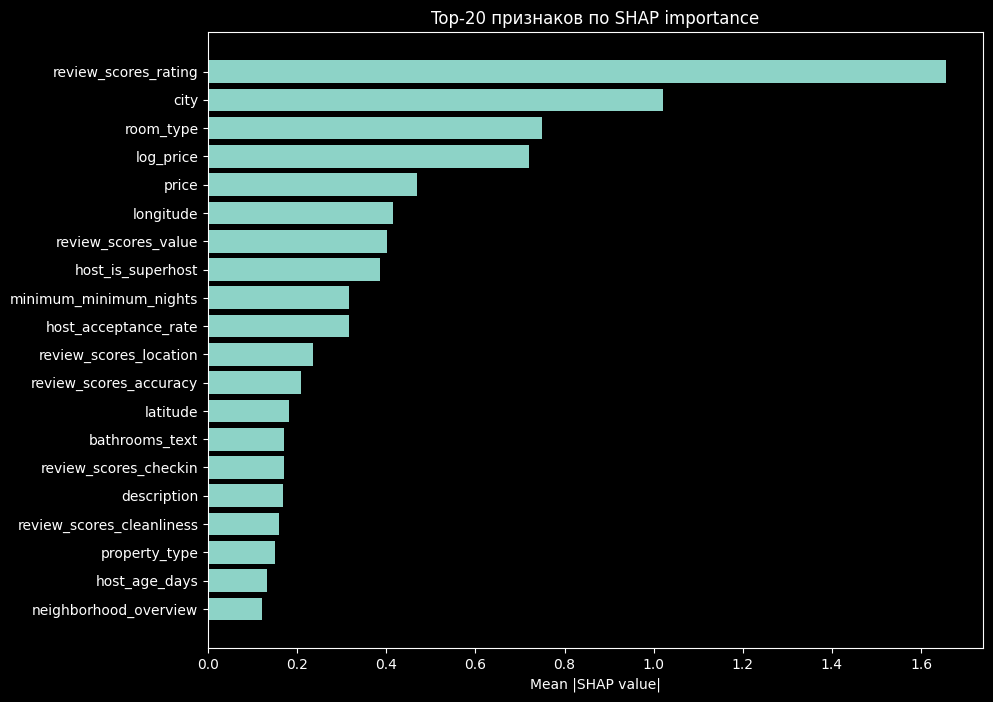

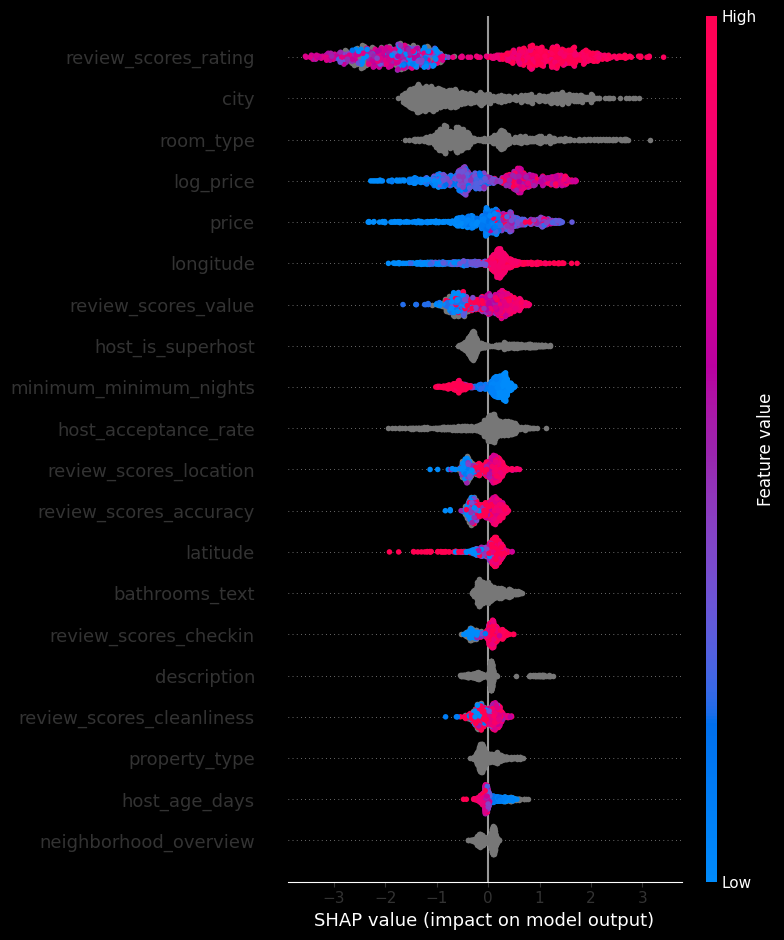

In [ ]:
# ==========================================
# SHAP анализ финальной CatBoost модели
# ==========================================

# ------------------------------------------
# 1. Подготовка данных
# ------------------------------------------

X_shap = X_valid.iloc[:1000].copy()


# обработка категориальных признаков
for col in cat_features:

    X_shap[col] = (
        X_shap[col]
        .fillna("missing")
        .astype(str)
    )


print(
    "X_shap shape:",
    X_shap.shape
)


print(
    "Ожидает модель:",
    final_model.n_features_in_
)


assert X_shap.shape[1] == final_model.n_features_in_



# ------------------------------------------
# 2. SHAP explainer
# ------------------------------------------

explainer = shap.TreeExplainer(
    final_model
)



# ------------------------------------------
# 3. SHAP values
# ------------------------------------------

shap_values = explainer.shap_values(
    X_shap
)


print(
    "SHAP shape:",
    np.array(shap_values).shape
)



# ------------------------------------------
# 4. Feature importance
# ------------------------------------------

importance_values = (
    np.abs(shap_values)
    .mean(axis=0)
)


feature_names = X_shap.columns.tolist()


shap_importance = pd.DataFrame({

    "feature": feature_names,

    "importance": importance_values

})


shap_importance = (
    shap_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)



print(
    "ТОП-20 признаков:"
)


display(
    shap_importance.head(20)
)



# ------------------------------------------
# 5. Bar plot
# ------------------------------------------

top20 = shap_importance.head(20)


plt.figure(
    figsize=(10,8)
)


plt.barh(
    top20["feature"],
    top20["importance"]
)


plt.gca().invert_yaxis()


plt.title(
    "Top-20 признаков по SHAP importance"
)


plt.xlabel(
    "Mean |SHAP value|"
)


plt.show()



# ------------------------------------------
# 6. Summary plot
# ------------------------------------------

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    max_display=20
)

**Интерпретация SHAP-анализа:**

1. По SHAP-графику видно, что модель сильнее всего опирается на review_scores_rating, затем на price, longitude, log_price и признак Private room. 

Также заметны вклад latitude, review_scores_value и, в меньшей степени, набор остальных рейтинговых и хостовых признаков.

2. Какие признаки важны: 

На верхних строках summary plot находятся признаки с наибольшим средним то есть с самым заметным влиянием на прогноз. По графику топ выглядит так:
- num__review_scores_rating.
- num__price.
- num__longitude.
- num__log_price.
- cat__room_type_Private room.
- num__latitude.
- num__review_scores_value.

3. Модель в основном опирается на цену, качество отзывов, локацию и тип жилья. Это значит, что прогнозы не случайны, а строятся на понятных факторах, которые реально влияют на результат.

SHAP важен, потому что показывает, почему модель дала именно такой прогноз. Это помогает доверять модели, быстро находить проблемные места и понимать, какие параметры стоит улучшать, чтобы повысить результат.

## 9. Карточка модели

Оформите карточку финальной версии модели по шаблону ниже.

## Модель v1.0

**Задача:** бинарная классификация — прогнозирование высокого спроса на объявление.

**Целевая переменная:** `is_high_demand`.

### Алгоритм

**CatBoostClassifier** (градиентный бустинг на решающих деревьях) с подбором гиперпараметров при помощи **Optuna**.

### Лучшие гиперпараметры

- `iterations`: 984
- `learning_rate`: 0.09884029114511485
- `depth`: 10
- `l2_leaf_reg`: 7.448977085781507
- `random_strength`: 2.2944742347560387
- `bagging_temperature`: 0.6931644036003485
- `loss_function`: `Logloss`
- `eval_metric`: `PRAUC`
- `auto_class_weights`: `Balanced`

### Используемые признаки

В финальную модель вошли:

- числовые признаки;
- категориальные признаки;
- текстовые признаки (`description`, `neighborhood_overview` и др.), обрабатываемые встроенными средствами CatBoost;
- признаки, полученные на этапе Feature Engineering.

Перед обучением были выполнены:

- заполнение пропусков с использованием статистик, рассчитанных на обучающей выборке;
- создание дополнительных признаков;
- очистка текстов (удаление стоп-слов и служебных символов);
- обработка дисбаланса классов с помощью `auto_class_weights="Balanced"`.

### Метрики качества

| Датасет | ROC-AUC | PR-AUC | F1 | Precision | Recall |
|---------|---------:|--------:|----:|----------:|-------:|
| Validation | **0.9936** | **0.9527** | **0.8709** | **0.7969** | **0.9599** |
| Test | **0.9938** | **0.9548** | **0.8704** | **0.7939** | **0.9631** |

### Интерпретация модели

Для интерпретации использовался метод **SHAP**, позволивший определить наиболее значимые признаки модели.

Наибольший вклад в прогноз внесли:

1. `review_scores_rating`
2. `city`
3. `room_type`
4. `log_price`
5. `price`
6. `longitude`
7. `review_scores_value`
8. `host_is_superhost`
9. `minimum_minimum_nights`
10. `host_acceptance_rate`

Полученные результаты хорошо согласуются с выводами разведочного анализа данных. Наибольшее влияние на вероятность высокого спроса оказывают рейтинг объявления, расположение объекта, тип жилья, стоимость размещения и характеристики владельца.

**Топ-5 важных признаков по SHAP:**

1. *[review_scores_rating]*
2. *[city]*
3. *[room_type]*
4. *[log_price]*
5. *[price]*

**Ограничения модели:**

- Модель может ошибаться на новых объектах, характеристики которых сильно отличаются от данных, использованных при обучении.
- При наличии изменений в поведении пользователей и рыночных условий качество прогнозирования может снижаться.

**Рекомендация к внедрению:** Да.

Модель рекомендуется к внедрению, так как показывает высокое качество на тестовой выборке и стабильные результаты относительно валидации. Значение ROC-AUC 0.9947 и высокий Recall (0.9591) показывают, что модель эффективно выявляет объявления с высоким спросом. Перед промышленным использованием рекомендуется проводить регулярный мониторинг качества и переобучение модели при изменении данных.

## 10. Итоговые выводы и рекомендации бизнесу

Напишите краткое резюме для бизнеса: что вы обучили, какого результата достигли, что рекомендуете.

**Выводы:**

## Итоговые выводы и рекомендации бизнесу

В рамках проекта была разработана модель машинного обучения для решения задачи бинарной классификации — прогнозирования высокого спроса на объявление (`is_high_demand`).

В ходе работы была выполнена подготовка данных, создание признаков, обработка категориальных и числовых данных, учет дисбаланса классов и сравнение нескольких алгоритмов классификации. Были протестированы Logistic Regression, CatBoost, LightGBM и XGBoost. По результатам экспериментов лучшей моделью была выбрана **CatBoost**.

Финальная модель показала высокое качество на тестовой выборке:
- ROC-AUC — **0.9938**;
- F1-score — **0.8704**;
- Precision — **0.7939**;
- Recall — **0.9631**.

Модель эффективно выявляет объявления с высоким потенциалом спроса: высокий показатель Recall позволяет находить большинство востребованных объектов, а значение Precision показывает достаточно высокую точность таких прогнозов.

Проверка на тестовой выборке показала стабильность модели: метрики практически не отличаются от результатов на валидационной выборке, что говорит об отсутствии выраженного переобучения.

### Рекомендации бизнесу

Модель рекомендуется использовать для предварительной оценки потенциала спроса на новые объявления. Ее можно применять для:
- выявления объектов с высокой вероятностью повышенного спроса;
- поддержки решений по продвижению объявлений;
- оптимизации маркетинговых активностей;
- помощи владельцам объявлений в повышении привлекательности объектов.

Перед внедрением в промышленную эксплуатацию рекомендуется:
- регулярно отслеживать качество модели на новых данных;
- периодически переобучать модель при изменении рыночных условий;
- дополнительно анализировать важность признаков и причины изменения спроса.

Таким образом, разработанная модель является эффективным инструментом прогнозирования высокого спроса и может использоваться для принятия бизнес-решений.